In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
import seaborn as sns
import streamlit as st
import io

In [2]:
df = pd.read_csv(r'C:\Users\Lakshya\Documents\Data_Sets\books.csv')

In [3]:
print(df.columns.tolist())

['BookID', 'Title', 'Authors', 'Average_Rating', 'ISBN', 'ISBN13', 'Language_Code', 'Num_Pages', 'Ratings_Count', 'Text_Reviews_Count', 'Publication_Date', 'Publisher']


In [4]:
df.head(10)

,BookID,Title,Authors,Average_Rating,ISBN,ISBN13,Language_Code,Num_Pages,Ratings_Count,Text_Reviews_Count,Publication_Date,Publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,439785960,9.78E+12,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,439358078,9.78E+12,eng,870,2153167,29221,09-01-2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,439554896,9.78E+12,eng,352,6333,244,11-01-2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9.78E+12,eng,435,2339585,36325,05-01-2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,439682584,9.78E+12,eng,2690,41428,164,9/13/2004,Scholastic
5,9,"Unauthorized Harry Potter Book Seven News: ""Ha...",W. Frederick Zimmerman,3.74,976540606,9.78E+12,en-US,152,19,1,4/26/2005,Nimble Books
6,10,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,439827604,9.78E+12,eng,3342,28242,808,09-12-2005,Scholastic
7,12,The Ultimate Hitchhiker's Guide: Five Complete...,Douglas Adams,4.38,517226952,9.78E+12,eng,815,3628,254,11-01-2005,Gramercy Books
8,13,The Ultimate Hitchhiker's Guide to the Galaxy ...,Douglas Adams,4.38,345453743,9.78E+12,eng,815,249558,4080,4/30/2002,Del Rey Books
9,14,The Hitchhiker's Guide to the Galaxy (Hitchhik...,Douglas Adams,4.22,1400052920,9.78E+12,eng,215,4930,460,08-03-2004,Crown


In [5]:
print(df['Publication_Date'].dtypes)

object


In [6]:
df['Publication_Date'] = df['Publication_Date'].astype(str).str.replace('/', '-', regex=False)
df['Publication_Date'] = pd.to_datetime(df['Publication_Date'], dayfirst=False, errors='coerce')
df['Publication_Date'] = df['Publication_Date'].dt.strftime('%d-%m-%Y')

In [7]:
#Remove extra column with NaN values.
# df = df.drop(columns=['Unnamed: 12'])

In [8]:
print(df['Publication_Date'])

0        16-09-2006
1        01-09-2004
2        01-11-2003
3        01-05-2004
4        13-09-2004
            ...    
11122    21-12-2004
11123    01-12-1988
11124    01-08-1993
11125    27-02-2007
11126    28-05-2006
Name: Publication_Date, Length: 11127, dtype: object


In [9]:
df

,BookID,Title,Authors,Average_Rating,ISBN,ISBN13,Language_Code,Num_Pages,Ratings_Count,Text_Reviews_Count,Publication_Date,Publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,439785960,9.78E+12,eng,652,2095690,27591,16-09-2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,439358078,9.78E+12,eng,870,2153167,29221,01-09-2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,439554896,9.78E+12,eng,352,6333,244,01-11-2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9.78E+12,eng,435,2339585,36325,01-05-2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,439682584,9.78E+12,eng,2690,41428,164,13-09-2004,Scholastic
...,...,...,...,...,...,...,...,...,...,...,...,...
11122,45631,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,1560254416,9.78E+12,eng,512,156,20,21-12-2004,Da Capo Press
11123,45633,You Bright and Risen Angels,William T. Vollmann,4.08,140110879,9.78E+12,eng,635,783,56,01-12-1988,Penguin Books
11124,45634,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,140131965,9.78E+12,eng,415,820,95,01-08-1993,Penguin Books
11125,45639,Poor People,William T. Vollmann,3.72,60878827,9.78E+12,eng,434,769,139,27-02-2007,Ecco


In [10]:
# Convert necessary columns to numeric types
df['Average_Rating'] = pd.to_numeric(df['Average_Rating'], errors='coerce')
df['Ratings_Count'] = pd.to_numeric(df['Ratings_Count'], errors='coerce')
df['Num_Pages'] = pd.to_numeric(df['Num_Pages'], errors='coerce')

**<h1 style="font-size: 30px;">Some Opeartions with Numpy</h1>**

**Count of non-missing values:**

In [11]:
print(df['Average_Rating'].count())

11123


**Minimum and Maximum values:**

In [12]:
print("Minimum Pages: ", df['Num_Pages'].min())

df['Num_Pages'] = pd.to_numeric(df['Num_Pages'], errors='coerce')
print("Maximum Pages: ", df['Num_Pages'].max())

Minimum Pages:  0.0
Maximum Pages:  6576.0


**Filter Books with Num_Pages in a Certain Range (100-500):**

In [13]:
df[np.logical_and(df['Num_Pages'] >= 100, df['Num_Pages'] <= 500)]

,BookID,Title,Authors,Average_Rating,ISBN,ISBN13,Language_Code,Num_Pages,Ratings_Count,Text_Reviews_Count,Publication_Date,Publisher
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,439554896,9.78E+12,eng,352.0,6333,244,01-11-2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9.78E+12,eng,435.0,2339585,36325,01-05-2004,Scholastic Inc.
5,9,"Unauthorized Harry Potter Book Seven News: ""Ha...",W. Frederick Zimmerman,3.74,976540606,9.78E+12,en-US,152.0,19,1,26-04-2005,Nimble Books
9,14,The Hitchhiker's Guide to the Galaxy (Hitchhik...,Douglas Adams,4.22,1400052920,9.78E+12,eng,215.0,4930,460,03-08-2004,Crown
14,23,Bryson's Dictionary of Troublesome Words: A Wr...,Bill Bryson,3.87,767910435,9.78E+12,eng,256.0,2088,131,14-09-2004,Broadway Books
...,...,...,...,...,...,...,...,...,...,...,...,...
11120,45626,O Príncipe Caspian (As Crónicas de Nárnia #4),C.S. Lewis/Pauline Baynes/Ana Falcão Bastos,3.97,9722330977,9.79E+12,por,160.0,215,11,11-10-2003,Editorial Presença
11121,45630,Whores for Gloria,William T. Vollmann,3.69,140231579,9.78E+12,en-US,160.0,932,111,01-02-1994,Penguin Books
11124,45634,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,140131965,9.78E+12,eng,415.0,820,95,01-08-1993,Penguin Books
11125,45639,Poor People,William T. Vollmann,3.72,60878827,9.78E+12,eng,434.0,769,139,27-02-2007,Ecco


**Find Index of Book with Maximum Text Reviews:**

In [14]:
print(np.argmax(df['Text_Reviews_Count'].values))

10340


**Get Mean and Std Dev of Ratings:**

In [15]:
print(np.mean(df['Average_Rating']), np.std(df['Average_Rating']))

3.9340753393868564 0.35046955631595733


**Rating Tier Assignment:**

In [16]:
df['Average_Rating'] = pd.to_numeric(df['Average_Rating'], errors='coerce')
def assign_rating_tiers(ratings):
    # Define bin edges and matching labels
    bins = np.array([0, 3.0, 4.0, 4.5, np.inf])  # 4 bins → 4 categories
    labels = np.array(['Poor', 'Average', 'Good', 'Excellent'])

    # Start with "Unknown" by default
    tiers = np.full(ratings.shape, 'Unknown', dtype=object)

    # Find non-NaN values to apply binning
    valid_mask = ~np.isnan(ratings)
    valid_ratings = ratings[valid_mask]

    # Digitize and map to labels safely
    bin_indices = np.digitize(valid_ratings, bins) - 1
    tiers[valid_mask] = labels[bin_indices]

    return tiers

# Apply to your dataset
df['Rating_Tier'] = assign_rating_tiers(df['Average_Rating'].values)
print(df['Rating_Tier'])

0        Excellent
1             Good
2             Good
3        Excellent
4        Excellent
           ...    
11122         Good
11123         Good
11124      Average
11125      Average
11126      Average
Name: Rating_Tier, Length: 11127, dtype: object


**Find Books with Extreme Pages or Ratings:**

In [17]:
def detect_outliers(arr, threshold=1):
    z_scores = (arr - np.nanmean(arr)) / np.nanstd(arr)
    return np.abs(z_scores) > threshold

df['Is_Page_Outlier'] = detect_outliers(df['Num_Pages'].values)
df['Is_Rating_Outlier'] = detect_outliers(df['Average_Rating'].values)
print(df['Is_Rating_Outlier'].head(50))

0      True
1      True
2      True
3      True
4      True
5     False
6      True
7      True
8      True
9     False
10    False
11     True
12    False
13     True
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21     True
22     True
23     True
24     True
25     True
26     True
27    False
28    False
29    False
30    False
31     True
32     True
33    False
34    False
35    False
36    False
37     True
38    False
39    False
40    False
41    False
42    False
43    False
44     True
45    False
46    False
47    False
48     True
49    False
Name: Is_Rating_Outlier, dtype: bool


**Create a Book Score:**

In [18]:
def min_max_normalize(array):
    min_val = np.nanmin(array)
    max_val = np.nanmax(array)
    if max_val - min_val == 0:
        return np.zeros_like(array)  # avoid division by zero
    return (array - min_val) / (max_val - min_val)

def compute_score(ratings, counts, pages):
    # Normalize all features
    norm_r = min_max_normalize(ratings)
    norm_c = min_max_normalize(counts)
    norm_p = min_max_normalize(pages)
    
    # Weighted score: favor rating & popularity more than length
    score = (0.5 * norm_r) + (0.4 * norm_c) + (0.1 * norm_p)
    return score

df['Book_Score'] = compute_score(df['Average_Rating'].values,
                                 df['Ratings_Count'].values,
                                 df['Num_Pages'].values)

df['Book_Score'] = (df['Book_Score'] * 10).round(2)
print(df['Book_Score'])

0        6.49
1        6.50
2        4.48
3        6.66
4        5.23
         ... 
11122    4.14
11123    4.18
11124    4.02
11125    3.79
11126    3.95
Name: Book_Score, Length: 11127, dtype: float64


**Find Books Closest to a Target Rating:**

In [19]:
def get_closest_books(target, n=5):
    diffs = np.abs(df['Average_Rating'].values - target)
    indices = np.argsort(diffs)[:n]
    return df.iloc[indices]

closest_books = get_closest_books(4.3)
closest_books

,BookID,Title,Authors,Average_Rating,ISBN,ISBN13,Language_Code,Num_Pages,Ratings_Count,Text_Reviews_Count,Publication_Date,Publisher,Rating_Tier,Is_Page_Outlier,Is_Rating_Outlier,Book_Score
6109,22915,The Complete Brothers Grimm Fairy Tales,Jacob Grimm/Wilhelm Grimm,4.3,517229250,9.78E+12,en-US,680.0,4420,165,03-10-2006,Gramercy Books,Good,True,True,4.41
5341,19315,Happy Times in Noisy Village,Astrid Lindgren/Ilon Wikland/Florence Lamborn,4.3,1883937663,9.78E+12,eng,128.0,600,35,01-07-2003,Ignatius Press,Good,False,True,4.32
10530,42898,Lover Revealed (Black Dagger Brotherhood #4),J.R. Ward,4.3,451412354,9.78E+12,eng,480.0,106469,3691,06-03-2007,Onyx,Good,False,True,4.47
11056,45350,Suffering and the Sovereignty of God,John Piper/Justin Taylor/Mark Talbot/David A. ...,4.3,1581348096,9.78E+12,eng,254.0,652,47,13-09-2006,Crossway Books,Good,False,True,4.34
4494,16192,You Can't Be Neutral on a Moving Train: A Pers...,Howard Zinn,4.3,807071277,9.78E+12,eng,214.0,2543,141,05-09-2002,Beacon Press,Good,False,True,4.33


In [20]:
# Define rolling average function
def rolling_avg_rating(arr, window=5):
    return np.convolve(arr, np.ones(window)/window, mode='same')

**Rolling Average Rating:**

In [21]:
# 1. Create a copy sorted by Publication_Date
df_sorted = df.sort_values('Publication_Date')

# 2. Compute rolling average rating on sorted data
rolling = rolling_avg_rating(df_sorted['Average_Rating'].fillna(0).values)
print(rolling)

# 3. Assign back to original DataFrame using index alignment
df['Rolling_Avg_Rating'] = pd.Series(rolling, index=df_sorted.index).sort_index()

[2.358 3.222 4.008 ... 1.612 1.612 1.612]


**<p style="font-size: 30px;">Some Operations with Pandas<p>**

**Top Authors by Number of Books:**

In [22]:
print(df['Authors'].value_counts().head(10))

Authors
Stephen King           40
P.G. Wodehouse         40
Rumiko Takahashi       39
Orson Scott Card       35
Agatha Christie        33
Piers Anthony          30
Mercedes Lackey        29
Sandra Brown           29
Dick Francis           28
Laurell K. Hamilton    23
Name: count, dtype: int64


**Top Rated Books (Min 1000 ratings):**

In [23]:
top_rated = df[df['Ratings_Count'] > 1000].sort_values(by='Average_Rating', ascending=False).head(10)
# print(top_rated)
top_rated

,BookID,Title,Authors,Average_Rating,ISBN,ISBN13,Language_Code,Num_Pages,Ratings_Count,Text_Reviews_Count,Publication_Date,Publisher,Rating_Tier,Is_Page_Outlier,Is_Rating_Outlier,Book_Score,Rolling_Avg_Rating
6590,24812,The Complete Calvin and Hobbes,Bill Watterson,4.82,740748475,9.78E+12,eng,1456.0,32213,930,06-09-2005,Andrews McMeel Publishing,Excellent,True,True,5.07,4.220
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,439682584,9.78E+12,eng,2690.0,41428,164,13-09-2004,Scholastic,Excellent,True,True,5.23,4.102
6592,24814,It's a Magical World (Calvin and Hobbes #11),Bill Watterson,4.76,836221362,9.78E+12,eng,176.0,23875,303,01-09-1996,Andrews McMeel Publishing,Excellent,False,True,4.81,4.360
6,10,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,439827604,9.78E+12,eng,3342.0,28242,808,12-09-2005,Scholastic,Excellent,True,True,5.26,4.116
6593,24816,Homicidal Psycho Jungle Cat (Calvin and Hobbes...,Bill Watterson,4.72,836217691,9.78E+12,eng,176.0,15365,290,06-09-1994,Andrews McMeel Publishing,Excellent,False,True,4.76,4.046
6596,24820,Calvin and Hobbes: Sunday Pages 1985-1995: An ...,Bill Watterson,4.71,740721356,9.78E+12,eng,96.0,3613,85,17-09-2001,Andrews McMeel Publishing,Excellent,False,True,4.73,4.210
6500,24520,The Complete Aubrey/Maturin Novels (5 Volumes),Patrick O'Brian,4.70,039306011X,9.78E+12,eng,6576.0,1338,81,17-10-2004,W. W. Norton Company,Excellent,True,True,5.70,4.002
5616,20749,Study Bible: NIV,Anonymous,4.70,310929555,9.78E+12,eng,2198.0,4166,186,01-10-2002,Zondervan Publishing House,Excellent,True,True,5.04,4.170
6594,24818,The Days Are Just Packed,Bill Watterson,4.69,836217357,9.78E+12,eng,176.0,20308,244,01-09-1993,Andrews McMeel Publishing,Excellent,False,True,4.73,4.080
1530,5309,The Life and Times of Scrooge McDuck,Don Rosa,4.67,911903968,9.78E+12,eng,266.0,2467,149,01-06-2005,Gemstone Publishing,Excellent,False,True,4.71,4.428


**Group by Publisher and get average rating:**

In [24]:
publisher_avg = df.groupby('Publisher')['Average_Rating'].mean().sort_values(ascending=False).head(10)
print(publisher_avg)

Publisher
University Press of New England    5.0
Vantage Press                      5.0
Boosey & Hawkes Inc                5.0
Square One Publishers              5.0
Texas A&M University Press         5.0
Chartwell Books                    5.0
Schirmer Mosel                     5.0
Y Lolfa                            5.0
Academica Press                    5.0
T&T Clark Int'l                    5.0
Name: Average_Rating, dtype: float64


**Convert Publication_Date to datetime format:**

In [25]:
df['Publication_Date'] = pd.to_datetime(df['Publication_Date'], errors='coerce', dayfirst=True)
print(df['Publication_Date'].dtype)

datetime64[ns]


**Number of Books per Year:**

In [26]:
df['Year'] = df['Publication_Date'].dt.year
books_per_year = df['Year'].value_counts().sort_index()
print(books_per_year)

Year
1900.0    1
1913.0    1
1914.0    1
1919.0    1
1921.0    2
         ..
2016.0    6
2017.0    7
2018.0    5
2019.0    6
2020.0    1
Name: count, Length: 87, dtype: int64


**Books with Missing Data:**

In [27]:
print(df.isnull().sum())

BookID                0
Title                 0
Authors               0
Average_Rating        4
ISBN                  0
ISBN13                0
Language_Code         0
Num_Pages             4
Ratings_Count         0
Text_Reviews_Count    0
Publication_Date      6
Publisher             0
Rating_Tier           0
Is_Page_Outlier       0
Is_Rating_Outlier     0
Book_Score            4
Rolling_Avg_Rating    0
Year                  6
dtype: int64


**Average Page Count by Language:**

In [28]:
df.groupby('Language_Code')['Num_Pages'].mean().sort_values(ascending=False)

Language_Code
enm         1060.333333
msa          784.000000
nl           744.000000
glg          741.000000
ale          512.000000
mul          437.263158
grc          413.363636
tur          403.000000
ita          400.600000
ger          391.979798
rus          371.500000
spa          365.793578
ara          349.000000
fre          339.000000
eng          336.797373
en-US        330.439631
zho          321.857143
en-GB        315.509346
swe          267.000000
en-CA        252.000000
gla          250.000000
srp          222.000000
por          219.800000
lat          200.333333
jpn          190.869565
nor          185.000000
wel          150.000000
9.78E+12            NaN
Name: Num_Pages, dtype: float64

**Group-Aware Ranking Within Publisher:**

In [29]:
df['Publisher_Rank'] = df.groupby('Publisher')['Book_Score'].rank(ascending=False, method='dense')
print(df['Publisher_Rank'])

0         3.0
1         2.0
2         4.0
3         1.0
4         2.0
         ... 
11122     6.0
11123    34.0
11124    49.0
11125    12.0
11126     3.0
Name: Publisher_Rank, Length: 11127, dtype: float64


**Multi-Condition Filtering Using .query() for Readability:**

In [30]:
high_quality_books = df.query(
    "Average_Rating >= 4.3 and Ratings_Count > 10000 and Num_Pages.between(200, 800)"
)
# print(high_quality_books)
high_quality_books

,BookID,Title,Authors,Average_Rating,ISBN,ISBN13,Language_Code,Num_Pages,Ratings_Count,Text_Reviews_Count,Publication_Date,Publisher,Rating_Tier,Is_Page_Outlier,Is_Rating_Outlier,Book_Score,Rolling_Avg_Rating,Year,Publisher_Rank
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,439785960,9.78E+12,eng,652.0,2095690,27591,2006-09-16,Scholastic Inc.,Excellent,True,True,6.49,3.988,2006.0,3.0
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9.78E+12,eng,435.0,2339585,36325,2004-05-01,Scholastic Inc.,Excellent,False,True,6.66,4.068,2004.0,1.0
23,34,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. Tolkien,4.36,618346252,9.78E+12,eng,398.0,2128944,13670,2003-09-05,Houghton Mifflin Harcourt,Good,False,True,6.27,4.188,2003.0,1.0
25,36,The Lord of the Rings: Weapons and Warfare,Chris Smith/Christopher Lee/Richard Taylor,4.53,618391002,9.78E+12,eng,218.0,19822,46,2003-11-05,Houghton Mifflin Harcourt,Excellent,False,True,4.58,4.102,2003.0,8.0
73,122,The Power of One (The Power of One #1),Bryce Courtenay,4.35,034541005X,9.78E+12,eng,544.0,69167,4551,1996-09-29,Ballantine Books,Good,False,True,4.49,3.976,1996.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10530,42898,Lover Revealed (Black Dagger Brotherhood #4),J.R. Ward,4.30,451412354,9.78E+12,eng,480.0,106469,3691,2007-03-06,Onyx,Good,False,True,4.47,3.854,2007.0,1.0
10532,42900,Lover Awakened (Black Dagger Brotherhood #3),J.R. Ward,4.45,451219368,9.78E+12,eng,448.0,144906,5728,2006-09-05,Signet,Good,False,True,4.64,4.034,2006.0,1.0
10533,42909,All Things Wise and Wonderful,James Herriot,4.41,312335288,9.78E+12,eng,448.0,22780,366,2004-11-01,St. Martin's Griffin,Good,False,True,4.50,4.246,2004.0,1.0
10679,43509,Harry Potter and the Goblet of Fire (Harry Pot...,J.K. Rowling,4.56,074754624X,9.78E+12,eng,636.0,18754,906,2000-07-08,Bloomsbury,Excellent,True,True,4.67,4.084,2000.0,1.0


**<p style="font-size: 30px">Some Operations with Matplotlib<p>**

**Compare values across categories (e.g., books, authors):**

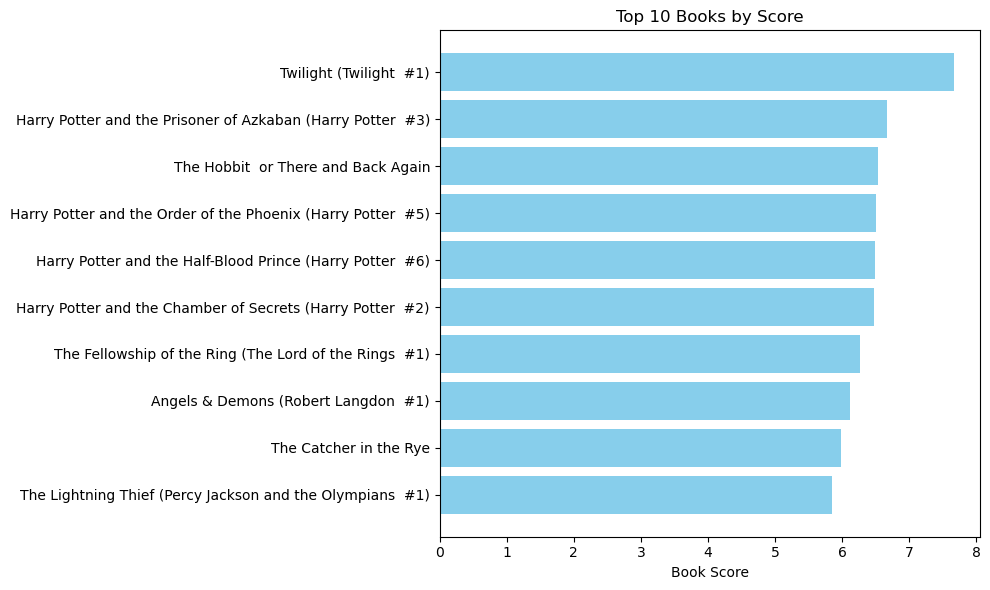

In [31]:
# Bar Plot:

top_books = df.nlargest(10, 'Book_Score')
plt.figure(figsize=(10, 6))
plt.barh(top_books['Title'], top_books['Book_Score'], color='skyblue')
plt.xlabel("Book Score")
plt.title("Top 10 Books by Score")
plt.gca().invert_yaxis()  # Highest at top
plt.tight_layout()
plt.show()

**Distribution of a numeric feature (e.g., ratings, pages):**

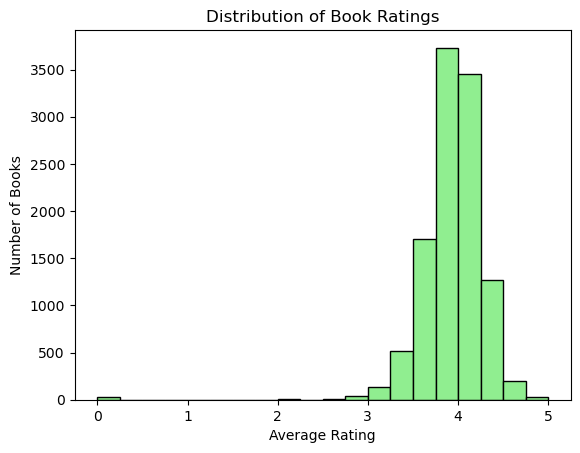

In [32]:
# Histogram:

plt.hist(df['Average_Rating'].dropna(), bins=20, edgecolor='black', color='lightgreen')
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Ratings")
plt.show()

**Trend over time (e.g., average rating by publication date):**

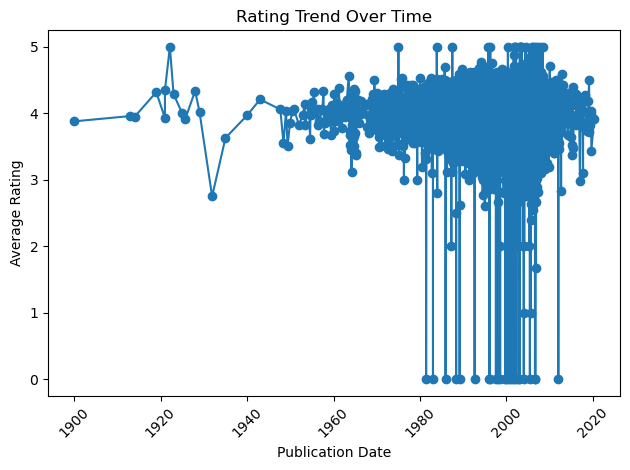

In [33]:
# Line Plot:

df_date = df.sort_values('Publication_Date')
plt.plot(df_date['Publication_Date'], df_date['Average_Rating'], marker='o', linestyle='-')
plt.xlabel("Publication Date")
plt.ylabel("Average Rating")
plt.title("Rating Trend Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Relationship between two variables (e.g., rating vs. popularity):**

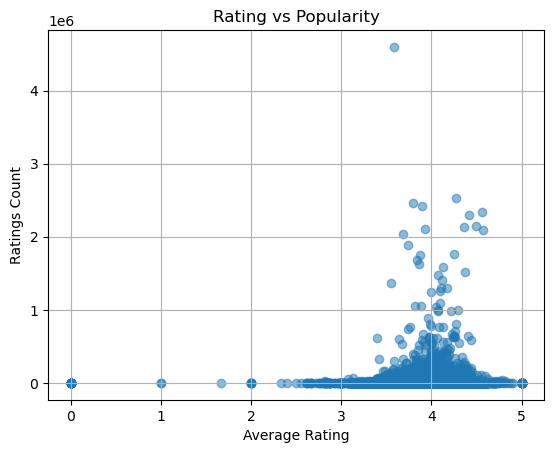

In [34]:
# Scatter Plot:

plt.scatter(df['Average_Rating'], df['Ratings_Count'], alpha=0.5)
plt.xlabel("Average Rating")
plt.ylabel("Ratings Count")
plt.title("Rating vs Popularity")
plt.grid(True)
plt.show()

**Proportion of languages, publishers, etc:**

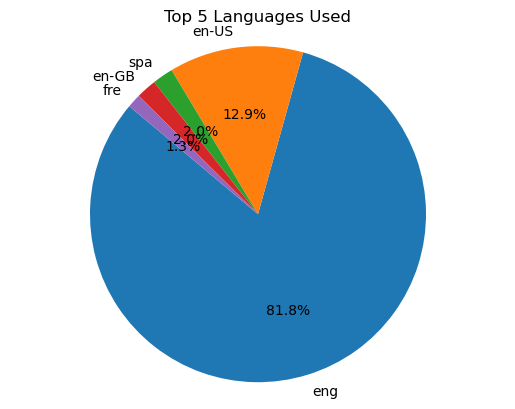

In [35]:
# Pie Chart: 

lang_counts = df['Language_Code'].value_counts().head(5)
plt.pie(lang_counts, labels=lang_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Top 5 Languages Used")
plt.axis('equal')
plt.show()

**Distribution + outliers in ratings or page numbers:**

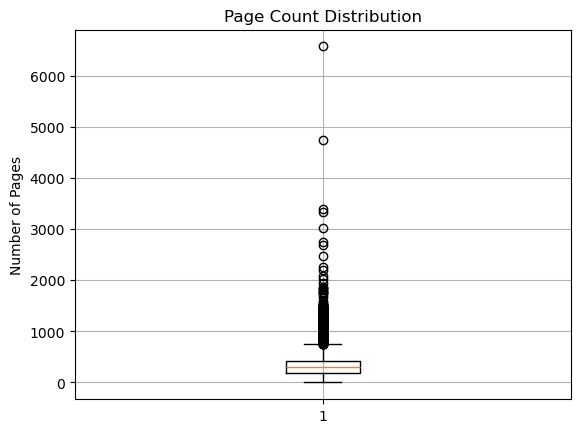

In [36]:
# Box Plot:

plt.boxplot(df['Num_Pages'].dropna())
plt.title("Page Count Distribution")
plt.ylabel("Number of Pages")
plt.grid(True)
plt.show()

**Detect numeric feature relationships:**

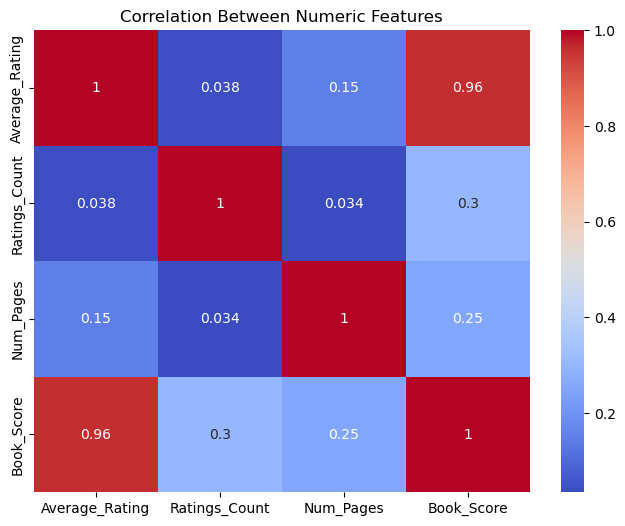

In [37]:
#Heatmap (Correlation Matrix):

numeric_cols = ['Average_Rating', 'Ratings_Count', 'Num_Pages', 'Book_Score']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()

**Compare grouped categories (e.g., rating tiers by language):**

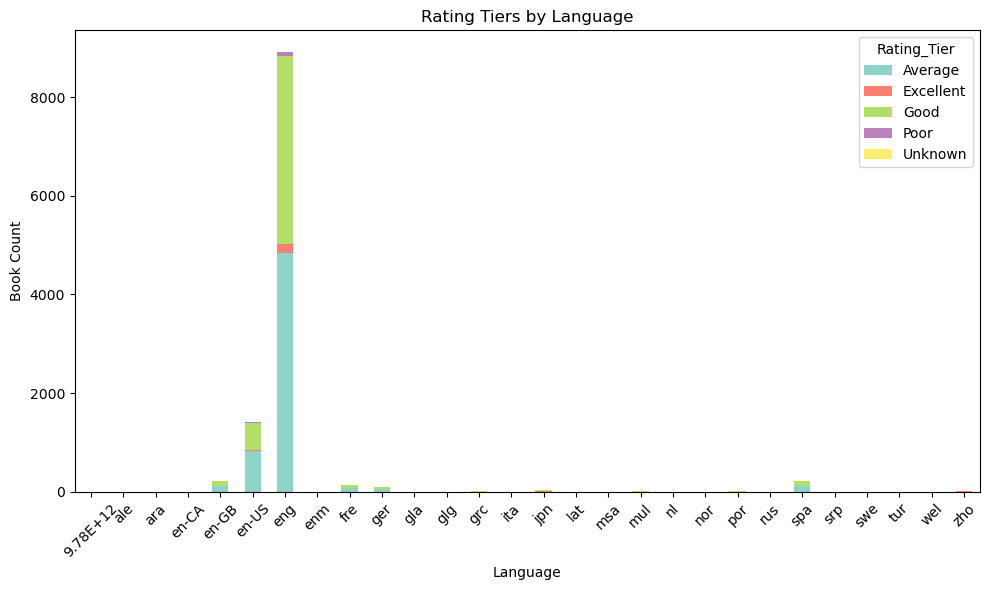

In [38]:
#Stacked Bar Plot:

tier_lang = pd.crosstab(df['Language_Code'], df['Rating_Tier'])

tier_lang.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set3')
plt.title("Rating Tiers by Language")
plt.ylabel("Book Count")
plt.xlabel("Language")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Top 10 Books:**

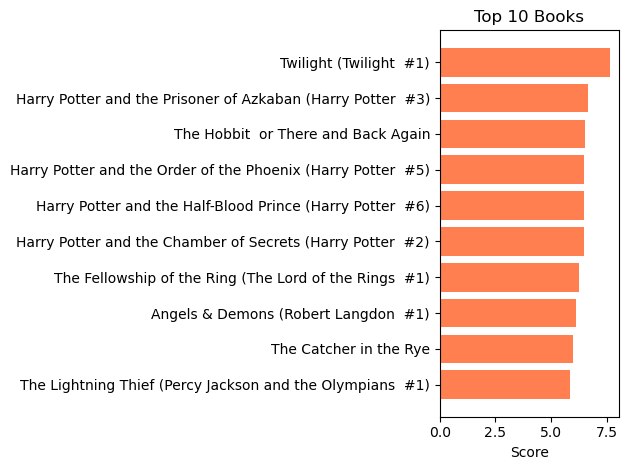

In [39]:
# Horizontal Bar Chart:

top_books = df.nlargest(10, 'Book_Score')
plt.barh(top_books['Title'], top_books['Book_Score'], color='coral')
plt.xlabel("Score")
plt.title("Top 10 Books")
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

**Compare trends (e.g., ratings vs decayed ratings):**

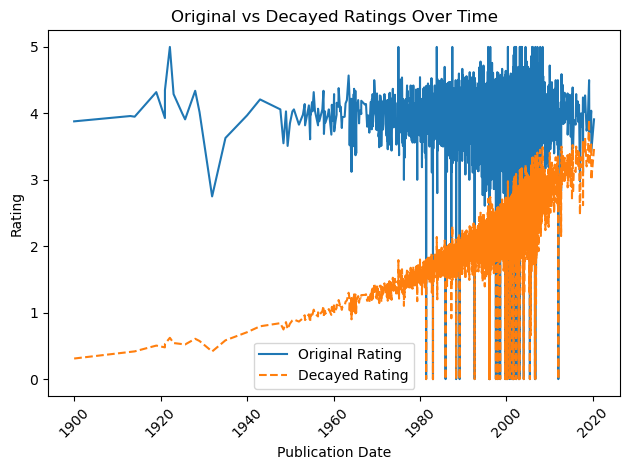

In [40]:
# Multi-Line Plot:

# Ensure publication date is parsed
df['Publication_Date'] = pd.to_datetime(df['Publication_Date'], errors='coerce', dayfirst=True)

# Compute age in years (from today)
df['Book_Age_Years'] = (datetime.now() - df['Publication_Date']).dt.days / 365

# Apply a simple decay: newer books keep more of their rating
decay_factor = 0.02  # adjust this to control decay strength
df['Decayed_Rating'] = df['Average_Rating'] * np.exp(-decay_factor * df['Book_Age_Years'])


df_sorted = df.sort_values('Publication_Date')

plt.plot(df_sorted['Publication_Date'], df_sorted['Average_Rating'], label='Original Rating')
plt.plot(df_sorted['Publication_Date'], df_sorted['Decayed_Rating'], label='Decayed Rating', linestyle='--')
plt.xlabel("Publication Date")
plt.ylabel("Rating")
plt.title("Original vs Decayed Ratings Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Compare average scores per group:**

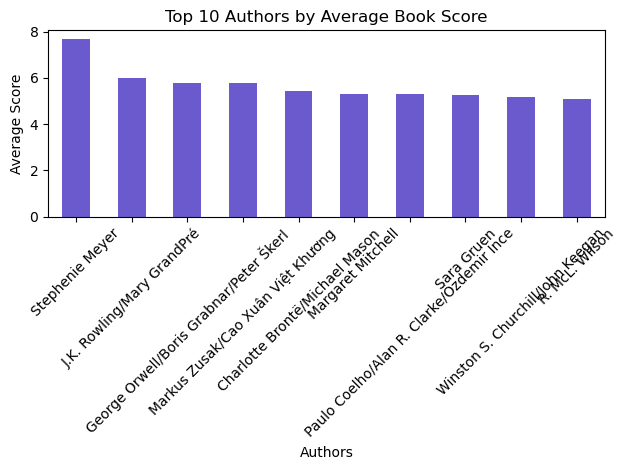

In [41]:
# Bar Plot by Group (Author or Publisher):

top_authors = df.groupby('Authors')['Book_Score'].mean().nlargest(10)

top_authors.plot(kind='bar', color='slateblue')
plt.ylabel("Average Score")
plt.title("Top 10 Authors by Average Book Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Smooth version of histogram:**

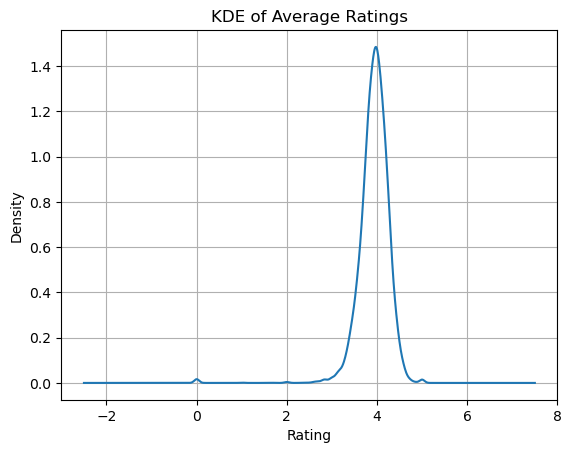

In [42]:
# Kernel Density Plot:

df['Average_Rating'].plot(kind='kde')
plt.title("KDE of Average Ratings")
plt.xlabel("Rating")
plt.grid(True)
plt.show()

**Scatter plot with size as third variable:**

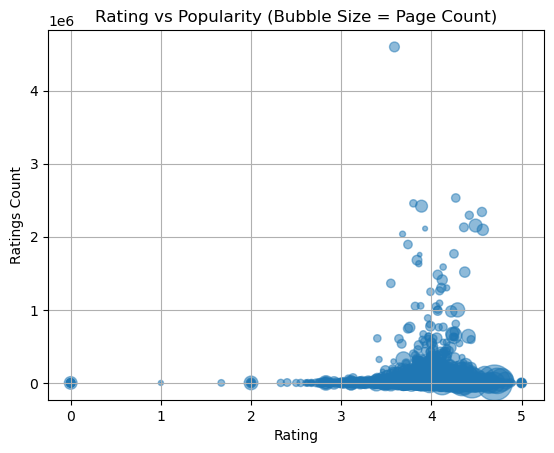

In [43]:
# Bubble Plot:

plt.scatter(
    df['Average_Rating'], 
    df['Ratings_Count'], 
    s=df['Num_Pages'] / 10,  # bubble size
    alpha=0.5
)
plt.xlabel("Rating")
plt.ylabel("Ratings Count")
plt.title("Rating vs Popularity (Bubble Size = Page Count)")
plt.grid(True)
plt.show()

**Subplots (Multiple Graphs Together):**

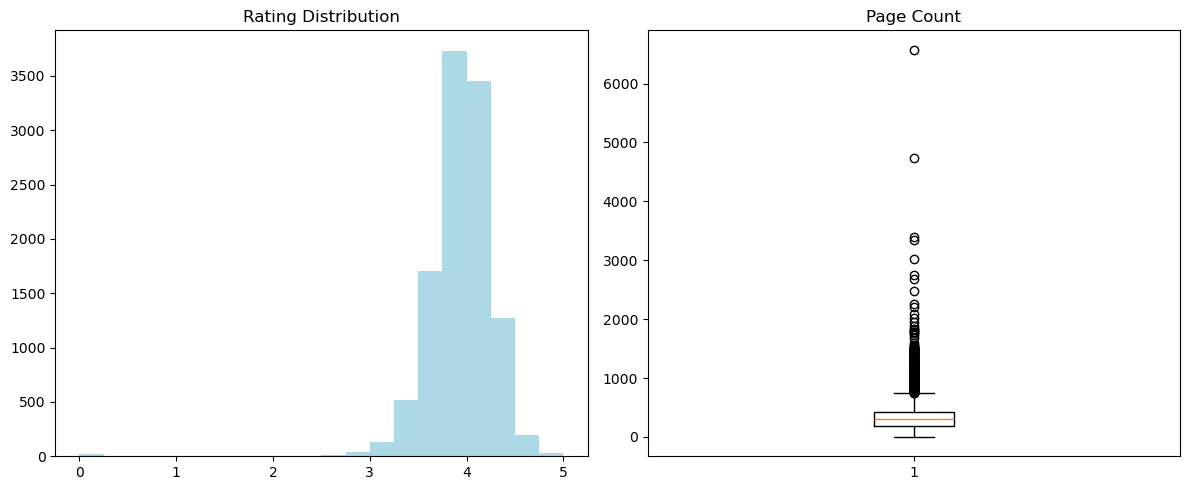

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axs[0].hist(df['Average_Rating'].dropna(), bins=20, color='lightblue')
axs[0].set_title("Rating Distribution")

# Boxplot
axs[1].boxplot(df['Num_Pages'].dropna())
axs[1].set_title("Page Count")

plt.tight_layout()
plt.show()

**<h1 style="font-size: 30px">Dashboard Script</h1>**

2026-04-17 18:59:22.108 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 18:59:24.078 
  command:

    streamlit run C:\Users\Lakshya\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-17 18:59:24.080 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 18:59:24.087 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 18:59:24.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 18:59:24.091 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 18:59:24.093 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 18:59:24.096 Session state does no

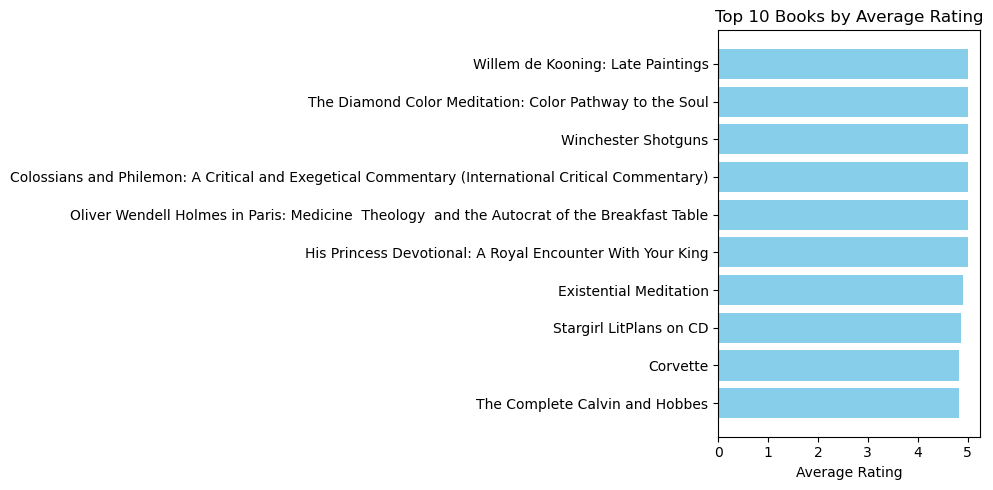

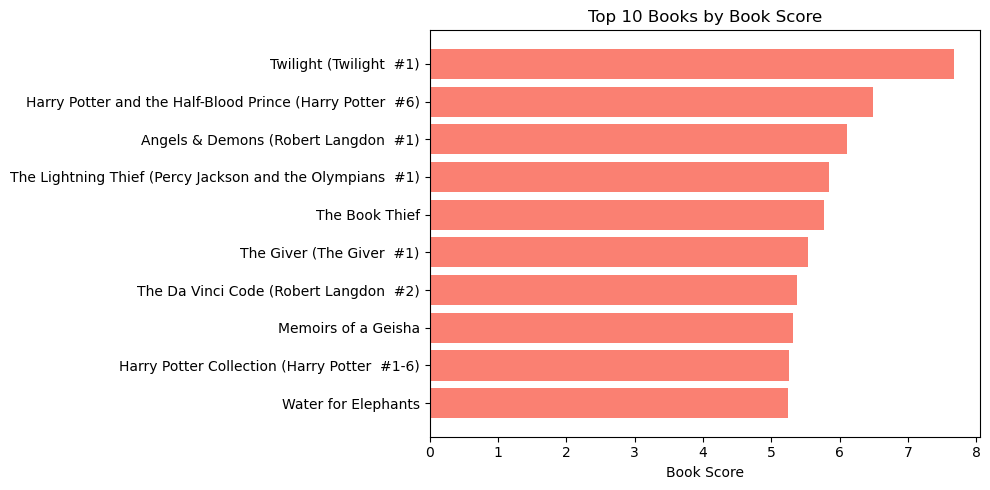

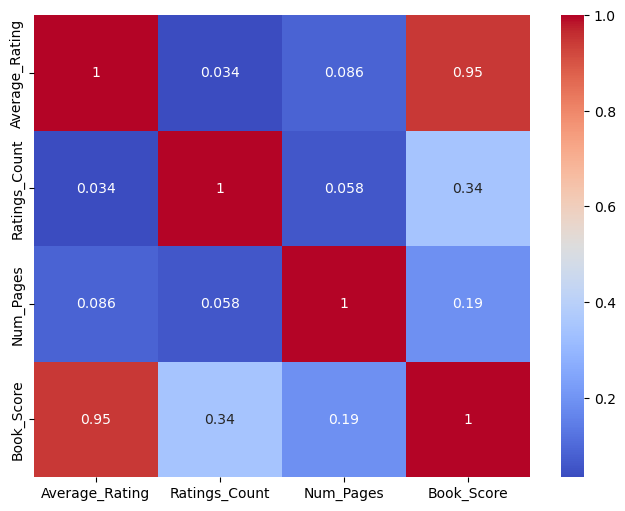

In [45]:
# books_dashboard.py

# ---------------- NumPy Functions ---------------- #
def assign_rating_tiers(ratings):
    bins = np.array([0, 3.0, 4.0, 4.5, np.inf])
    labels = np.array(['Poor', 'Average', 'Good', 'Excellent'])
    tiers = np.full(ratings.shape, 'Unknown', dtype=object)
    valid_mask = ~np.isnan(ratings)
    valid_ratings = ratings[valid_mask]
    bin_indices = np.digitize(valid_ratings, bins) - 1
    tiers[valid_mask] = labels[bin_indices]
    return tiers

def detect_outliers(arr, threshold=1):
    # handle constant arrays or all-nan arrays gracefully
    if np.nanstd(arr) == 0 or np.all(np.isnan(arr)):
        return np.zeros_like(arr, dtype=bool)
    z_scores = (arr - np.nanmean(arr)) / np.nanstd(arr)
    return np.abs(z_scores) > threshold

def min_max_normalize(array):
    min_val = np.nanmin(array)
    max_val = np.nanmax(array)
    if np.isnan(min_val) or np.isnan(max_val) or max_val - min_val == 0:
        return np.zeros_like(array)
    return (array - min_val) / (max_val - min_val)

def compute_score(ratings, counts, pages):
    # convert to numpy arrays and handle NaNs
    r = np.array(ratings, dtype=float)
    c = np.array(counts, dtype=float)
    p = np.array(pages, dtype=float)
    norm_r = min_max_normalize(r)
    norm_c = min_max_normalize(c)
    norm_p = min_max_normalize(p)
    score = (0.5 * norm_r) + (0.4 * norm_c) + (0.1 * norm_p)
    return np.round(score * 10, 2)

def get_closest_books(df, target, n=5):
    # returns n books with average rating closest to target
    if 'Average_Rating' not in df.columns:
        return pd.DataFrame()
    diffs = np.abs(df['Average_Rating'].values - target)
    indices = np.argsort(diffs)[:n]
    return df.iloc[indices]

def rolling_avg_rating(arr, window=10):
    a = np.array(arr, dtype=float)
    if len(a) == 0:
        return a
    if len(a) < window or window <= 1:
        # fallback to simple mean smoothing
        kernel = np.ones(len(a)) / len(a)
        return np.convolve(np.nan_to_num(a), kernel, mode='same')
    kernel = np.ones(window) / window
    return np.convolve(np.nan_to_num(a), kernel, mode='same')

# ---------------- Load Data ---------------- #
# @st.cache_data
def load_data(path=r"C:\Users\Lakshya\Documents\Data_Sets\books.csv"):
    df = pd.read_csv(path, encoding='utf-8', low_memory=False)
    # remove any Unnamed junk columns
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Convert types safely
    df['Publication_Date'] = pd.to_datetime(df['Publication_Date'], errors='coerce', dayfirst=True)
    df['Average_Rating'] = pd.to_numeric(df['Average_Rating'], errors='coerce')
    df['Ratings_Count'] = pd.to_numeric(df['Ratings_Count'], errors='coerce')
    df['Text_Reviews_Count'] = pd.to_numeric(df['Text_Reviews_Count'], errors='coerce')
    df['Num_Pages'] = pd.to_numeric(df['Num_Pages'], errors='coerce')

    # Sort and reset
    df = df.sort_values('Publication_Date').reset_index(drop=True)

    # NumPy features
    df['Rating_Tier'] = assign_rating_tiers(df['Average_Rating'].values)
    df['Is_Page_Outlier'] = detect_outliers(df['Num_Pages'].values)
    df['Is_Rating_Outlier'] = detect_outliers(df['Average_Rating'].values)
    df['Book_Score'] = compute_score(df['Average_Rating'].values,
                                     df['Ratings_Count'].values,
                                     df['Num_Pages'].values)
    df['Rolling_Avg_Rating'] = rolling_avg_rating(df['Average_Rating'].fillna(0).values)
    return df

# ---------------- Sidebar / Filters ---------------- #
st.sidebar.header("🔎 Filters")

# language choices with 'All' option
languages = sorted(df['Language_Code'].dropna().unique().tolist())
languages = ["All"] + languages
lang = st.sidebar.selectbox("Language", languages, index=0)

# safe year bounds
years_series = df['Publication_Date'].dropna().dt.year
if len(years_series) == 0:
    min_year, max_year = 1900, datetime.now().year
else:
    min_year = int(years_series.min())
    max_year = int(years_series.max())
default_start = max(min_year, max_year - 15)
year_range = st.sidebar.slider("Publication Year Range", min_year, max_year, (default_start, max_year))

# extra interactive selectors
min_rating = st.sidebar.slider("Minimum Average Rating", 0.0, 5.0, 0.0, step=0.1)
min_ratings_count = st.sidebar.number_input("Minimum Ratings Count", min_value=0, value=0, step=100)

# Apply filters to create filtered_df
filtered_df = df.copy()
if lang != "All":
    filtered_df = filtered_df[filtered_df['Language_Code'] == lang]
filtered_df = filtered_df[filtered_df['Publication_Date'].dt.year.between(year_range[0], year_range[1])]
filtered_df = filtered_df[filtered_df['Average_Rating'].fillna(0) >= min_rating]
filtered_df = filtered_df[filtered_df['Ratings_Count'].fillna(0) >= min_ratings_count]

# ---------------- Header / KPIs ---------------- #
st.title("📚 Book Analytics Dashboard")

# show raw data toggle
if st.checkbox("Show Raw Data (top 5 rows)"):
    st.dataframe(df.head())

col1, col2, col3 = st.columns(3)
col1.metric("Total Books (filtered)", len(filtered_df))
col2.metric("Avg Rating (filtered)", round(filtered_df['Average_Rating'].mean() if not filtered_df.empty else 0, 2))
top_pub = filtered_df['Publisher'].mode()[0] if (not filtered_df.empty and 'Publisher' in filtered_df.columns and len(filtered_df['Publisher'].dropna())>0) else "N/A"
col3.metric("Top Publisher (filtered)", top_pub)

# quick download button for CSV
csv_buffer = io.StringIO()
filtered_df.to_csv(csv_buffer, index=False)
st.download_button("📥 Download CSV", csv_buffer.getvalue(), file_name="books.csv", mime="text/csv")

# ---------------- Tabs ---------------- #
tab1, tab2, tab3 = st.tabs(["⚡ NumPy Operations", "📑 Pandas Operations", "📊 Visual Analytics"])

# =====================================================
# ---------------- NumPy Based Visuals ----------------
# =====================================================
with tab1:
    st.header("NumPy-based Insights (filtered data)")

    # Top 10 Books by Average Rating (filtered)
    st.subheader("Top 10 Books by Average Rating")
    if filtered_df.empty:
        st.info("No data for selected filters.")
    else:
        top_books = filtered_df.nlargest(10, 'Average_Rating').dropna(subset=['Average_Rating'])
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh(top_books['Title'].astype(str), top_books['Average_Rating'], color='skyblue')
        ax.invert_yaxis()
        ax.set_xlabel("Average Rating")
        ax.set_title("Top 10 Books by Average Rating")
        plt.tight_layout()
        st.pyplot(fig)

    # Top 10 Books by Book Score
    st.subheader("Top 10 Books by Book Score")
    if filtered_df.empty:
        st.info("No data for selected filters.")
    else:
        top_score_books = filtered_df.nlargest(10, 'Book_Score').dropna(subset=['Book_Score'])
        fig2, ax2 = plt.subplots(figsize=(10, 5))
        ax2.barh(top_score_books['Title'].astype(str), top_score_books['Book_Score'], color='salmon')
        ax2.invert_yaxis()
        ax2.set_xlabel("Book Score")
        ax2.set_title("Top 10 Books by Book Score")
        plt.tight_layout()
        st.pyplot(fig2)

    # Rating Tier Distribution
    st.subheader("Rating Tiers Distribution")
    if filtered_df.empty:
        st.info("No data for selected filters.")
    else:
        rating_tier_counts = filtered_df['Rating_Tier'].value_counts()
        st.bar_chart(rating_tier_counts)

    # Outlier Summary
    st.subheader("Outlier Summary")
    st.write(f"Number of Page Outliers (filtered): {int(filtered_df['Is_Page_Outlier'].sum())}")
    st.write(f"Number of Rating Outliers (filtered): {int(filtered_df['Is_Rating_Outlier'].sum())}")

    # Rolling Average Rating Over Time
    st.subheader("Rolling Average Rating Over Time")
    if filtered_df.empty or filtered_df['Publication_Date'].dropna().empty:
        st.info("No publication-date data to show rolling average.")
    else:
        rolling_df = filtered_df.sort_values('Publication_Date')
        st.line_chart(rolling_df.set_index('Publication_Date')['Rolling_Avg_Rating'])

# =====================================================
# ---------------- Pandas Based Ops -------------------
# =====================================================
with tab2:
    st.header("Pandas Operations (filtered data)")

    st.subheader("Top Authors by Number of Books")
    if filtered_df.empty:
        st.info("No data for selected filters.")
    else:
        st.write(filtered_df['Authors'].value_counts().head(10))

    st.subheader("Top Rated Books (Min 1000 Ratings)")
    top_rated = filtered_df[filtered_df['Ratings_Count'] > 1000].sort_values(by='Average_Rating', ascending=False).head(10)
    st.write(top_rated[['Title', 'Authors', 'Average_Rating', 'Ratings_Count']])

    st.subheader("Average Rating by Publisher")
    publisher_avg = filtered_df.groupby('Publisher')['Average_Rating'].mean().sort_values(ascending=False).head(10)
    st.bar_chart(publisher_avg)

    st.subheader("Books per Year")
    # create Year column if not exists
    filtered_df['Year'] = filtered_df['Publication_Date'].dt.year
    books_per_year = filtered_df['Year'].value_counts().sort_index()
    st.line_chart(books_per_year)

    st.subheader("Books with Missing Data (full dataset)")
    st.write(df.isnull().sum())

    st.subheader("Average Page Count by Language")
    avg_pages = filtered_df.groupby('Language_Code')['Num_Pages'].mean().sort_values(ascending=False).head(10)
    st.bar_chart(avg_pages)

    # Group-aware ranking within publisher
    if 'Book_Score' in filtered_df.columns and 'Publisher' in filtered_df.columns:
        filtered_df['Publisher_Rank'] = filtered_df.groupby('Publisher')['Book_Score'].rank(ascending=False, method='dense')
        st.subheader("Publisher Rank (sample)")
        st.write(filtered_df[['Title', 'Publisher', 'Book_Score', 'Publisher_Rank']].head(10))

    # Example of multi-condition filtering using .query()
    st.subheader("High Quality Books (example query)")
    try:
        high_quality_books = filtered_df.query(
            "Average_Rating >= 4.3 and Ratings_Count > 10000 and Num_Pages.between(200, 800)"
        )
        st.write(high_quality_books[['Title', 'Authors', 'Average_Rating', 'Ratings_Count', 'Num_Pages']].head(10))
    except Exception:
        st.info("Query had no results or was invalid for filtered data.")

# =====================================================
# --------------- Matplotlib / Seaborn Ops -----------
# =====================================================
with tab3:
    st.header("Matplotlib & Seaborn Visual Analytics (filtered data)")

    # Top 10 Books by Score
    st.subheader("Top 10 Books by Score")
    if filtered_df.empty:
        st.info("No data for selected filters.")
    else:
        top_books_score = filtered_df.nlargest(10, 'Book_Score').dropna(subset=['Book_Score'])
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(top_books_score['Title'].astype(str), top_books_score['Book_Score'], color='coral')
        ax.invert_yaxis()
        ax.set_xlabel("Score")
        plt.tight_layout()
        st.pyplot(fig)
        plt.close(fig)

    # Distribution of Ratings (histogram)
    st.subheader("Distribution of Ratings")
    fig, ax = plt.subplots()
    ax.hist(filtered_df['Average_Rating'].dropna(), bins=20, edgecolor='black', color='lightgreen')
    ax.set_xlabel("Average Rating")
    ax.set_ylabel("Number of Books")
    st.pyplot(fig)
    plt.close(fig)

    # Rating Trend Over Time
    st.subheader("Rating Trend Over Time")
    if filtered_df['Publication_Date'].dropna().empty:
        st.info("No publication date data for trend.")
    else:
        df_date = filtered_df.sort_values('Publication_Date')
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(df_date['Publication_Date'], df_date['Average_Rating'], marker='o', linestyle='-')
        ax.set_xlabel("Publication Date")
        ax.set_ylabel("Average Rating")
        fig.autofmt_xdate()
        st.pyplot(fig)
        plt.close(fig)

    # Rating vs Popularity (scatter)
    st.subheader("Rating vs Popularity")
    fig, ax = plt.subplots()
    ax.scatter(filtered_df['Average_Rating'], filtered_df['Ratings_Count'], alpha=0.5)
    ax.set_xlabel("Average Rating")
    ax.set_ylabel("Ratings Count")
    st.pyplot(fig)
    plt.close(fig)

    # Top 5 Languages Used (Pie)
    st.subheader("Top 5 Languages Used (Pie)")
    lang_counts = filtered_df['Language_Code'].value_counts().head(5)
    if lang_counts.empty:
        st.info("No language data.")
    else:
        fig, ax = plt.subplots()
        ax.pie(lang_counts, labels=lang_counts.index, autopct='%1.1f%%', startangle=140)
        ax.set_title("Top 5 Languages Used")
        ax.axis('equal')
        st.pyplot(fig)
        plt.close(fig)

    # Page Count Distribution (Boxplot)
    st.subheader("Page Count Distribution (Boxplot)")
    fig, ax = plt.subplots()
    ax.boxplot(filtered_df['Num_Pages'].dropna())
    ax.set_ylabel("Number of Pages")
    st.pyplot(fig)
    plt.close(fig)

    # Correlation Heatmap
    st.subheader("Correlation Heatmap")
    numeric_cols = ['Average_Rating', 'Ratings_Count', 'Num_Pages', 'Book_Score']
    corr_df = filtered_df[numeric_cols].dropna(how='all')
    if corr_df.shape[0] < 2:
        st.info("Not enough numeric data for correlation heatmap.")
    else:
        fig3, ax3 = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', ax=ax3)
        st.pyplot(fig3)
        plt.close(fig)

    # Rating Tiers by Language (Stacked Bar)
    st.subheader("Rating Tiers by Language (Stacked Bar)")
    try:
        tier_lang = pd.crosstab(filtered_df['Language_Code'], filtered_df['Rating_Tier'])
        fig, ax = plt.subplots(figsize=(10, 6))
        tier_lang.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
        ax.set_ylabel("Book Count")
        plt.xticks(rotation=45)
        st.pyplot(fig)
        plt.close(fig)
    except Exception:
        st.info("Not enough data to build stacked bar.")

    # Original vs Decayed Ratings Over Time
    st.subheader("Original vs Decayed Ratings Over Time")
    if filtered_df['Publication_Date'].dropna().empty:
        st.info("No publication dates for decay plot.")
    else:
        df = filtered_df.copy()
        df['Book_Age_Years'] = (datetime.now() - df['Publication_Date']).dt.days / 365
        decay_factor = 0.02
        df['Decayed_Rating'] = df['Average_Rating'] * np.exp(-decay_factor * df['Book_Age_Years'])
        df_sorted = df.sort_values('Publication_Date')
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(df_sorted['Publication_Date'], df_sorted['Average_Rating'], label='Original Rating')
        ax.plot(df_sorted['Publication_Date'], df_sorted['Decayed_Rating'], label='Decayed Rating', linestyle='--')
        ax.legend()
        fig.autofmt_xdate()
        st.pyplot(fig)
        plt.close(fig)

    # Top 10 Authors by Average Book Score
    st.subheader("Top 10 Authors by Average Book Score")
    try:
        top_authors = filtered_df.groupby('Authors')['Book_Score'].mean().nlargest(10)
        fig, ax = plt.subplots(figsize=(10, 4))
        top_authors.plot(kind='bar', ax=ax, color='slateblue')
        plt.xticks(rotation=45)
        st.pyplot(fig)
        plt.close(fig)
    except Exception:
        st.info("Not enough data for top authors plot.")

    # KDE of Average Ratings
    st.subheader("KDE of Average Ratings")
    if filtered_df['Average_Rating'].dropna().empty:
        st.info("No ratings available for KDE.")
    else:
        fig, ax = plt.subplots()
        filtered_df['Average_Rating'].plot(kind='kde', ax=ax)
        st.pyplot(fig)
        plt.close(fig)

    # Bubble Plot: Rating vs Popularity (Bubble Size = Page Count)
    st.subheader("Bubble Plot: Rating vs Popularity (Bubble Size = Page Count)")
    fig, ax = plt.subplots()
    ax.scatter(filtered_df['Average_Rating'], filtered_df['Ratings_Count'], s=filtered_df['Num_Pages'].fillna(0) / 10, alpha=0.5)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Ratings Count")
    st.pyplot(fig)
    plt.close(fig)

    # Histogram + Boxplot Subplots
    st.subheader("Histogram + Boxplot Subplots")
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].hist(filtered_df['Average_Rating'].dropna(), bins=20, color='lightblue')
    axs[0].set_title("Rating Distribution")
    axs[1].boxplot(filtered_df['Num_Pages'].dropna())
    axs[1].set_title("Page Count")
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)


In [46]:
# import unicodedata

# chars = ["鋼", "之", "鍊", "金", "術", "師"]

# for c in chars:
#     print(c, hex(ord(c)), unicodedata.name(c))